### Anomaly Informed Remaining Useful Life Estimation (AIRULE) Using Hybrid LSTM models (June 2024)

available at: https://doi.org/10.1016/j.mex.2024.102555

### Initial Interpretation
- As a machine reaches failure, its RUL diminishes lineraly.
- However, estimating RUL prior the failure region is difficult

- This system not only informs the inception of anomalies but also forecasts the remaining operational life of the machinery.


- They use feature ranking and selection techniques
- They use unsupervised clustering algorithms for anomaly trend analysis & 

- Clip dataset an first signs of anomalies (not the entire dataset)

- RUL Regressor training & RUL prediction at the end

![AIRULE Methodology](./media/AIRULE_Method.png)

<br>
<hr>

### Informed Interpretation
Two parts (Methods essentialities):
1. Anomaly detection & anomaly onset identification
    Find when degredation begins (unsupervised)
2. Anomaly-triggered RUL estimation
    Once degredation begins (anomaly onset above), activate supervised model to predict RUL on only the degrading portion of the data

Super adaptable & versatile (use with any vibration sensor dataset!)

# Methodology

### Setting Constant Seed
Attempting to keep repoduction of AutoEncoder consistent (for the sake of setting up really)

In [35]:
import numpy as np
import tensorflow as tf
import random
#import os

SEED = 23
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


### Locating Dataset

In [36]:
import os, sys

DATASET_LOC = "./Datasets/"
NASA_BEARING_DATASET_LOC = DATASET_LOC + "NASABearing/"
DEBUG = True

# For all sets_directories (not files) in dataset dir - Path.join is concatenates full path str lit to directory
sets_directories = [os.path.join(NASA_BEARING_DATASET_LOC, d)+f"/{d}/" for d in  os.listdir(NASA_BEARING_DATASET_LOC) if os.path.isdir(os.path.join(NASA_BEARING_DATASET_LOC, d))]

## Select Dataset ##
DATASET_DIR_INUSE = sets_directories[0]

if DEBUG:
    print("Available sets in Dataset are:")
    for i, dir in enumerate(sets_directories):
        print(f"[{i}] {dir}")
    # Using set/run 2
    print(f"Using set: {DATASET_DIR_INUSE}")


print(f"Count of bursts/files: {len(os.listdir(DATASET_DIR_INUSE))}")

Available sets in Dataset are:
[0] ./Datasets/NASABearing/1st_test/1st_test/
Using set: ./Datasets/NASABearing/1st_test/1st_test/
Count of bursts/files: 2156


### Feature Extraction - Features are scalars used during learning stages (You don't use raw data)

11 Features Total (so far (12/01 14:58))

<ins>Time Domain</ins>

- RMS
- Std
- Peak-to-Peak (PTP)
- Kurtosis
- Skewness
- Crest factor

<ins>Frequency Domain</ins>

- Spectral bandwidth (spread of frequencies)
- spectral centroid (center of mass of spectrum)
- Spectral total energy (overall vibration energy)
- Peak frequency (dominant vibration frequency)
- High-frequency energy ratio (Early fault indicator?)

In dissertation, might be worth noting these equation formualas. e.g.
Spectral Centroid:
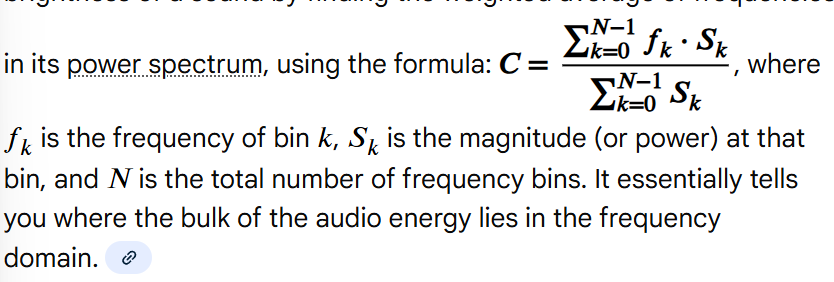

In [82]:
import numpy as np
#temp test
x = [1,2,3,5, 10]
print(np.ptp(x))
max(x)-min(x)

y = [-1,-6, 3, 9]
np.abs(y)

x = np.random.randn(20480)
X = np.fft.rfft(x)


# Magnitude Spectrum consists of Absolute (positives) where m_n >= 0
M = np.abs(X)


P_n = M / np.sum(M) 
F = len(P_n)
# Prevent NAN issue - log(0 or -P_n) = undefined (NaN) - This occurs becaues the first value in P_n is 0 
P_n_safe = P_n[P_n > 0]
  
SEN = -np.sum(P_n_safe * np.log2(P_n_safe)) / np.log2(F)
SEN


9


0.9845883560652483

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Must check dataset in use - check num rows in  one burst
DATAPOINTS_PER_FILE = 20480
SAMPLE_RATE = 20000 # 20 kHz


time_step = 1 / SAMPLE_RATE
# np.arange returns arr of evenly spaced values within the given interval 
# so a float timestamp that can be used in timedelta at the 
# files starting point (such 2004.02.19.06.22.39) - there are 20480 
# datapoints which need time indexing/stamping
# Kind reminds me of pandas resample method but for relative (not actual) time in a given time period
timestamps = np.arange(DATAPOINTS_PER_FILE) * time_step
#print(timestamps)

features = [
    # Time Domain Features
    "rms",
    "std",
    "ptp",
    "kurtosis",
    "skew",
    "crest",

    # Frequency Domain Features
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_total",
    "spectral_entropy",
    "frequency_peak"
]

df = pd.DataFrame(columns=features) #columns=["b1", "b2", "b3", "b4"])


## ---- Time Domain Features
# Feature	Meaning
# RMS	Overall vibration energy
# Std	Signal spread
# Mean	Should be ~0 (after de-meaning)
# Peak-to-peak	Max impulse size
# Kurtosis	Impulsiveness (very important)
# Skewness	Asymmetry
# Crest factor	Peak / RMS
## ---- Calcuation
# Where x the 20480 readings in a burst for the deterioted bearing (b1)
# Time Domain Features = {
#     "rms": np.sqrt(np.mean(x**2)),
#     "std": np.std(x),
#     "ptp": np.ptp(x),
#     "kurtosis": stats.kurtosis(x, fisher=False),
#     "skew": stats.skew(x),
#     "crest": np.max(np.abs(x)) / np.sqrt(np.mean(x**2))
# }
# Frequency Domain Features = {
#     ""
# }


BEARINGS_COUNT:int # not implemented sensor-fusion on single bearing (point) yet
CSV_DELIM:str = "\t"
# Parse & understand CSV files in dataset 
with open(DATASET_DIR_INUSE+os.listdir(DATASET_DIR_INUSE)[0]) as file:
    line = file.readline()
    NUMERICAL_CHARS = [".", "-", "+"] # Doesnt count unary values, decimal points as delimeters
    for char in line:
        if not char.isnumeric() and char not in NUMERICAL_CHARS:
            print(f"Suspected Delimiter: '{char}'")
            CSV_DELIM = char
            break
    cols = line.count(CSV_DELIM) + 1
    print(f"Bearings (coloums) found: {cols}")
    BEARINGS_COUNT = cols


temp_index = 0

for file_reading_interval in os.listdir(DATASET_DIR_INUSE):
    # Each iteration is a burst (file contains one burst)
    

    # print(file_reading_interval)
    time_interval_df = pd.read_csv(
        DATASET_DIR_INUSE+file_reading_interval, 
        delimiter=CSV_DELIM, 
        # [b1, b2, ..., bn]
        names=["b"+str(i+1) for i in range(BEARINGS_COUNT)], header=None)
    
    start = pd.to_datetime(file_reading_interval, format="%Y.%m.%d.%H.%M.%S")
    time_interval_df.index = start + pd.to_timedelta(timestamps, unit="s")

    # print(f"reading starts at: {time_interval_df.index[0]}")
    # print(f"reading ends at: {time_interval_df.index[-1]}")
    # print(time_interval_df)
    # break

    try:
        """Bearings Readings over this Signal"""
        bearings_readings = time_interval_df["b5"]
    except KeyError as err:
        print("\n[CAUGHT ERROR]: File(s) for set selected doesnt have this many columns?")
        break


    # TIME DOMAIN
    td_features_dict = {}
    
    # Numpy array
    x:list = np.asarray(bearings_readings)
    mu:float = np.mean(x)
    N:int = len(x)

    td_features_dict["id"] = file_reading_interval

    # Features Extraction 
    # Root Mean Square - Overall Energy in Signal
    RMS = np.sqrt(np.sum(x**2) / N)
    td_features_dict["rms"] = RMS # np.sqrt(np.mean(bearings_readings**2))
   

    # Standard Deviation - Spread/Var
    Std = np.sqrt(np.sum((x - mu)**2) / N)
    td_features_dict["std"] = Std # np.std(bearings_readings)
  
    
    # Peak to Peak - Distance from max and min
    Peak_max:float = np.max(x)
    Peak_min:float = np.min(x)
    PTP:float = Peak_max - Peak_min
    td_features_dict["ptp"] = PTP # np.ptp(bearings_readings)

    # Skewness - 3rd Central Moment - Symmetric difference (more prominant on negative or positive side)
    Sk = (np.sum((x-mu)**3)) / ((N-1)*td_features_dict["std"]**3)
    td_features_dict["skew"] = Sk # stats.skew(bearings_readings)


    # Kurtosis - 4th Central Moment - Determines flatness or peakiness (is the distribution more similar therefore flatter or does it contain some impulsive anomalies therefore peakier)
    Ku = (np.sum((x-mu)**4)) / ((N-1)*td_features_dict["std"]**4)
    td_features_dict["kurtosis"] = Ku #stats.kurtosis(bearings_readings, fisher=False)  # Fisher (if True) subtracts 3 from result (3 is standardised as normal distribution) so the normal distribution score is then 0.0
   
    # Crest Factor - Early warning sign for Impulsive Behaviour -  Indicates impact incuring within the bearing (contacts between the balls & the raceway track)
    # Takes max (Peak max) over the absolute values of x here: https://www.mdpi.com/2075-1702/5/4/21, the absolute x is not explicit here: https://www.researchgate.net/publication/286318685_Survey_of_condition_indicators_for_condition_monitoring_systems
    Peak_max_abs:float = np.max(np.abs(x))
    CF = Peak_max_abs / RMS
    td_features_dict["crest"] = CF
  




    # FREQUENCY DOMAIN
    fd_features_dict = {}
    # Convert Time-Domain to Frequency-Domain
    # FFT is the Fast Fourier Transform - It is the optimised Discrete Fourier Transform (DFT) 
    fft_b1_burst = np.fft.rfft(list(bearings_readings))
    
    # Magnitude Spectrum consists of Absolute (positives) where m_n >= 0
    magnitude = np.abs(fft_b1_burst)

    frequencies = np.fft.rfftfreq(len(bearings_readings), d=1/DATAPOINTS_PER_FILE) # 1/sample rate per burst (20480)
    # First reading is normally super high (the first value when using the FFT 
    # formular is set to the sum of all the samples in this signal instance - apprently)
    # so set it to 0 to remove this dominance
    magnitude[0] = 0

    # Index is n, n = 1, ... F Mathematically - n = 0, ..., F-1 Computationally
    F = len(frequencies)    
    

    # Bins in FFT are frequency slots (indicates strength of vibration at that frequency)
    # The readings (20480 rows) becoems: 20480 / 2 + 1 = 10241 frequency bins 
  

    # - spectral centroid (center of mass of spectrum)
    SC = np.sum(frequencies * magnitude) / np.sum(magnitude)
    fd_features_dict["spectral_centroid"] = SC

    # - Spectral bandwidth (spread of frequencies)
    SB = np.sqrt(np.sum(((frequencies - SC) ** 2) * magnitude) / np.sum(magnitude))
    fd_features_dict["spectral_bandwidth"] = SB

    # - Spectral Energy (Total overall vibration energy)
    SE = np.sum(magnitude**2)
    fd_features_dict["spectral_total"] = SE
    
    # NOTE - Using Spectal Entropy brought the triggered anomaly onset period back 2 days for the NASA DS, Set 1 (Earlier Warning!)
    # Spectral Entropy - Measure peakiness over the magnitude spectrum
    # P_n is Probabiltity Distribution - Found in literature typically, & MathWorks examples as P(m) where m is the sample (this fft frequency's bins) :) - n is indicies over our fft samples 
    P_n = magnitude / np.sum(magnitude) 
  
    # Prevent NAN issue - log(0 or -P_n) = undefined (NaN) - This occurs becaues the first value in P_n is 0 
    P_n_safe = P_n[P_n > 0]
  
    # TODO clarify this is correct
    SEN = -np.sum(P_n_safe * np.log2(P_n_safe)) / np.log2(F)
    fd_features_dict["spectral_entropy"] = SEN
    # Spectral entropy came down a tiny amount over the lifetime of the eventually broken bearing.


    # - Peak frequency (dominant vibration frequency)
    # np.argmax Finds & Returns the indices of the maximum values along an axis (idx of largest val in magnitude).
    fd_features_dict["frequency_peak"] = frequencies[np.argmax(magnitude)]


    # EXTRA (Unsed)
    # High Freqs energy ratio (threshold is >5kHz) 
    # - High-frequency energy ratio (Early fault indicator?)
    # THRESHOLD = 5000
    # fd_features_dict["high_frequency_ratio"] = np.sum(magnitude[frequencies > THRESHOLD]**2) / fd_features_dict["spectral_total"] 
    ##########


    features_dict = {**td_features_dict, **fd_features_dict}


    df.loc[len(df)] = features_dict

df.index = os.listdir(DATASET_DIR_INUSE)
df.index = pd.to_datetime(df.index, format="%Y.%m.%d.%H.%M.%S")


print(df)
print(f"{df.shape} (number of bursts ROW, number of features per burst COL)")

Suspected Delimiter: '	'
Bearings (coloums) found: 8
Spectral Entropy 0: 0.9749837282678783
Spectral Entropy 1: 0.9748281033188364
Spectral Entropy 2: 0.9752719776078674
Spectral Entropy 3: 0.9750273580613764
Spectral Entropy 4: 0.9752799063428921
Spectral Entropy 5: 0.9746627484688309
Spectral Entropy 6: 0.974746794206353
Spectral Entropy 7: 0.974994750498106
Spectral Entropy 8: 0.9754222923075129
Spectral Entropy 9: 0.9748386009398193
Spectral Entropy 10: 0.9750170247949165
Spectral Entropy 11: 0.9748539865363672
Spectral Entropy 12: 0.9754743463007887
Spectral Entropy 13: 0.9754239104660971
Spectral Entropy 14: 0.9753842753849847
Spectral Entropy 15: 0.9752165090743281
Spectral Entropy 16: 0.975492523460429
Spectral Entropy 17: 0.9753853461575791
Spectral Entropy 18: 0.9749951906354077
Spectral Entropy 19: 0.9749875432996472
Spectral Entropy 20: 0.9743917005031938
Spectral Entropy 21: 0.9749482998697724
Spectral Entropy 22: 0.9748392926906491
Spectral Entropy 23: 0.9749252542272869


2003-10-22 12:06:24    0.974984
2003-10-22 12:09:13    0.974828
2003-10-22 12:14:13    0.975272
2003-10-22 12:19:13    0.975027
2003-10-22 12:24:13    0.975280
                         ...   
2003-11-25 16:07:32    0.970580
2003-11-25 23:13:21    0.967167
2003-11-25 23:19:56    0.968123
2003-11-25 23:29:56    0.970938
2003-11-25 23:39:56    0.968646
Name: spectral_entropy, Length: 2156, dtype: float64


<Axes: >

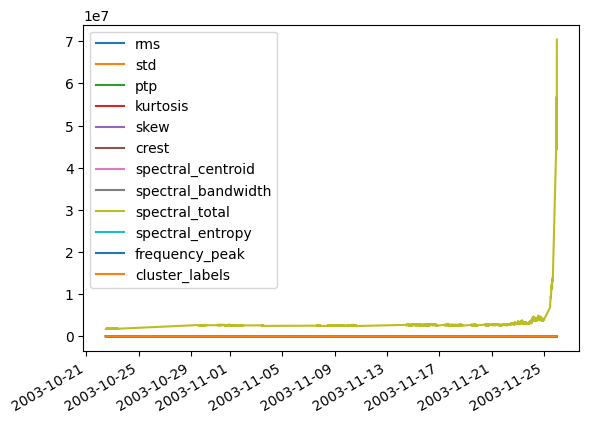

In [66]:
print(df["spectral_entropy"])

df.plot()

## Feature Normalisation (scaling all features to shared scale)
Imperative before using KMeans clustering. otherwise, larger spanning features (spectral energy) will be the dominating feature - all features should be fairly assessed.
 

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(df[features].values)

df_scaled = pd.DataFrame(features_scaled, columns=features, index=df.index)
df_scaled

,rms,std,ptp,kurtosis,skew,crest,spectral_centroid,spectral_bandwidth,spectral_total,spectral_entropy,frequency_peak
2003-10-22 12:06:24,-1.517142,-1.006162,-0.741126,-0.285287,0.265050,-0.666860,2.227271,1.175711,-0.455892,-1.459177,-0.083776
2003-10-22 12:09:13,-1.486066,-0.994771,-0.572654,-0.277977,0.082990,-0.491227,2.130776,0.973014,-0.451779,-1.621079,-0.083776
2003-10-22 12:14:13,-1.404271,-0.991382,-0.647071,-0.288141,0.367368,-0.421212,2.607660,1.276615,-0.450566,-1.159302,-0.083776
2003-10-22 12:19:13,-1.416060,-0.967358,-0.763865,-0.311325,-0.052433,-0.544394,2.478084,1.266384,-0.441844,-1.413788,-0.083776
2003-10-22 12:24:13,-1.405721,-0.986395,-0.635702,-0.299669,0.225157,-0.611103,2.484288,1.217155,-0.448767,-1.151054,-0.083776
...,...,...,...,...,...,...,...,...,...,...,...
2003-11-25 16:07:32,5.238909,5.659494,4.353350,0.394377,-0.413020,1.753588,-0.442181,-3.798136,4.019997,-6.040693,6.838514
2003-11-25 23:13:21,15.390989,15.435488,8.307796,1.768313,-0.629103,1.434653,2.575726,-10.253409,18.108109,-9.591386,9.922187
2003-11-25 23:19:56,17.020442,17.008779,8.567223,1.686527,-0.380960,1.209478,2.693045,-9.291209,21.211345,-8.596862,6.859813
2003-11-25 23:29:56,14.390809,14.455239,7.832353,1.344957,-1.585934,1.502859,1.403218,-8.124205,16.292311,-5.668146,9.917453


## KMeans Clustering
Clustering used to identify healthy vs abnormal datapoints (so no labels needed - making this approach an unsupervised learning!)

Binary Classification (strictly 2 labels can be devised)

label 0 = Health
- RMS = low vib energy
- Kurtosis around 3-4 (close to gaussian noise)
- High-Freq ratio low = no impulsive fault energy

label 1 = Unhealthy
- RMS = vib energy increaing
- kurtosis > 3.7 (using NASA bearing ds) = impulsive events
- High-Freq ratio higher = fault related frequencies


d:\Patrick\Uni\IP\Independent-Project-Contents\PdM\main\v\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


                     rms  kurtosis  spectral_entropy
cluster_labels                                      
0              -0.165859 -0.231158          0.140044
1               1.409440  1.964330         -1.190062


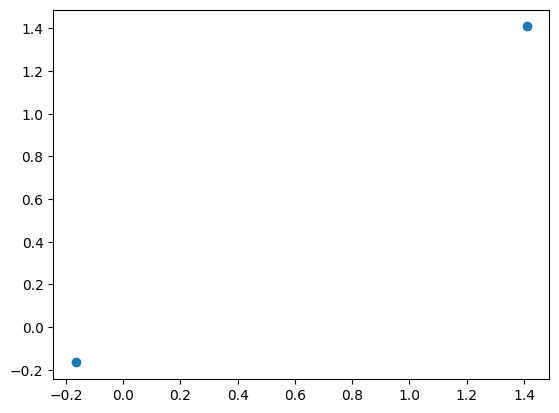

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# Two groups (healthy, unhealthy)
kmeans = KMeans(n_clusters=2, random_state=42).fit(features_scaled) # Do not include RUL nor time-indexing (just the feature columns)

df_scaled["cluster_labels"] = kmeans.labels_
df["cluster_labels"] = kmeans.labels_

# Aggregate by label (0, 1)
cluster_means = df_scaled.groupby("cluster_labels").mean()
print(cluster_means[["rms", "kurtosis", "spectral_entropy"]])


plt.scatter(cluster_means["rms"], cluster_means["rms"])
plt.show()

Lower RMS, Kurtosis, Spectral total & Spectral centroid agree that **label 0 is healthy** & **label 1 is degrading**

Looking at High-Frequency Feature: 

cluster 0 len: 1929
cluster 1 len: 227
Cluster 0 min-max: 0.974-0.978 (Spread is 0.004)
Cluster 1 min-max: 0.967-0.978 (Spread is 0.011)


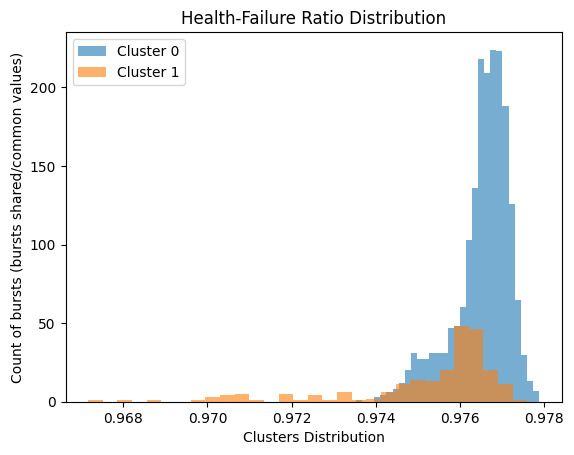

,rms,std,ptp,kurtosis,skew,crest,spectral_centroid,spectral_bandwidth,spectral_total,spectral_entropy,frequency_peak
cluster_labels,,,,,,,,,,,
0,0.15824,0.111091,1.327307,3.703890,0.004289,4.975692,4759.258002,2715.567911,2.596912e+06,0.976521,1010.006221
1,0.19246,0.152281,4.041264,15.802299,-0.170097,13.028901,4667.271378,2654.489243,5.600748e+06,0.975242,1346.162996


In [72]:
import matplotlib.pyplot as plt

cluster0 = df[df["cluster_labels"] == 0]
cluster1 = df[df["cluster_labels"] == 1]
print("Looking at High-Frequency Feature: \n")
print(f"cluster 0 len: {len(cluster0)}")
print(f"cluster 1 len: {len(cluster1)}")
c0_min = round(cluster0['spectral_entropy'].min(), 3); c0_max = round(cluster0['spectral_entropy'].max(), 3)
c1_min = round(cluster1['spectral_entropy'].min(), 3); c1_max = round(cluster1['spectral_entropy'].max(), 3)
print(f'Cluster 0 min-max: {c0_min}-{c0_max} (Spread is {round(c0_max - c0_min, 3)})')
print(f'Cluster 1 min-max: {c1_min}-{c1_max} (Spread is {round(c1_max - c1_min, 3)})')

# PLot
plt.hist(cluster0['spectral_entropy'], bins=30, alpha=0.6)
plt.hist(cluster1['spectral_entropy'], bins=30, alpha=0.6)
plt.xlabel("Clusters Distribution")
plt.ylabel("Count of bursts (bursts shared/common values)")
plt.legend(['Cluster 0', 'Cluster 1'])
plt.title('Health-Failure Ratio Distribution')
plt.show()

df.groupby('cluster_labels').mean()[features]

From above, can see Cluster 1 (anomalous values) are more spread on x axis, wheres in Cluster 0 (healthy values), they're tightly around the same healthy margin. 

Now we've got the seperation, we can use the healthy data (label 0) for the autoencoder!

In [45]:
#df_scaled

In [46]:
healthy_df = df_scaled.loc[df_scaled["cluster_labels"]==0][features]
healthy_data = healthy_df.values

print("Shape format here (bursts count/rows, features count/cols)")
print(f"Health labelled data: {healthy_data.shape} - (All data: {df_scaled.shape})")

# Sequence length is the amount of consecutive bursts to join together for assessing (rather than just 1 individual burst)
SEQUENCE_LENGTH = 20
healthy_sequences = []
for i in range(len(healthy_data) - SEQUENCE_LENGTH + 1):
    healthy_sequences.append(healthy_data[i:i+SEQUENCE_LENGTH])
healthy_sequences = np.array(healthy_sequences)


print(f"Sequences: {healthy_sequences.shape}")


Shape format here (bursts count/rows, features count/cols)
Health labelled data: (1929, 11) - (All data: (2156, 12))
Sequences: (1910, 20, 11)


## LSTM Auto Encoder!

Revise components in Sequential Model

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

features_count = len(features)

autoencoder = Sequential([
    # Input Layer - Using ReLU as paper, if exploding reconstruction error or dead neurons detected tne use tanh
    LSTM(64, activation="ReLU", input_shape=(SEQUENCE_LENGTH, features_count), return_sequences=False),
    RepeatVector(SEQUENCE_LENGTH), 
    # Output Layer
    LSTM(64, activation="ReLU", return_sequences=True),
    TimeDistributed(Dense(features_count))
])

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                19456     
                                                                 
 repeat_vector (RepeatVecto  (None, 20, 64)            0         
 r)                                                              
                                                                 
 lstm_1 (LSTM)               (None, 20, 64)            33024     
                                                                 
 time_distributed (TimeDist  (None, 20, 11)            715       
 ributed)                                                        
                                                                 
Total params: 53195 (207.79 KB)
Trainable params: 53195 (207.79 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [48]:
# Check data is scaled (MSE was enormous as was using unscaled data by accident)
print(healthy_data.shape)

print(f"Min: {healthy_data.min()}")
print(f"Max: {healthy_data.max()}")
print(f"Mean: {healthy_data.mean()}")
print(f"Std: {healthy_data.std()}")


(1929, 11)
Min: -2.974960811211383
Max: 4.193231973681413
Mean: -0.06717981201188376
Std: 0.4792558315514444


Now train the model with the healthy data

In [49]:
# Healthy Sequences is the healthy training data remember

history = autoencoder.fit(
    healthy_sequences,
    healthy_sequences,
    epochs=50,
    batch_size=32,
    validation_split=.1, # Ratio 
    shuffle=False
    )

print(f"Loss: {np.mean(history.history['loss'])}")
print(f"Val Loss: {np.mean(history.history['val_loss'])}")


Epoch 1/50
54/54 [==============================] - 3s 16ms/step - loss: 0.1570 - val_loss: 0.4648
Epoch 2/50
54/54 [==============================] - 1s 11ms/step - loss: 7.7834 - val_loss: 0.4039
Epoch 3/50
54/54 [==============================] - 1s 11ms/step - loss: 0.1483 - val_loss: 0.4119
Epoch 4/50
54/54 [==============================] - 1s 11ms/step - loss: 0.1046 - val_loss: 0.3857
Epoch 5/50
54/54 [==============================] - 1s 11ms/step - loss: 12.6461 - val_loss: 0.3981
Epoch 6/50
54/54 [==============================] - 1s 11ms/step - loss: 0.1599 - val_loss: 0.3811
Epoch 7/50
54/54 [==============================] - 1s 11ms/step - loss: 0.1339 - val_loss: 0.3397
Epoch 8/50
54/54 [==============================] - 1s 11ms/step - loss: 0.1044 - val_loss: 0.4079
Epoch 9/50
54/54 [==============================] - 1s 11ms/step - loss: 0.0840 - val_loss: 2.0562
Epoch 10/50
54/54 [==============================] - 1s 11ms/step - loss: 0.5176 - val_loss: 5835.7729
Epoch

All data (both healthy & unhealthy)

In [50]:
all_data = df_scaled[features].values
print(all_data.shape)


all_sequences = []
for i in range(len(all_data) - SEQUENCE_LENGTH + 1):
    all_sequences.append(all_data[i:i+SEQUENCE_LENGTH])
all_sequences = np.array(all_sequences)

all_sequences.shape

(2156, 11)


(2137, 20, 11)

Anomaly Scores (health indicators)

<br>
Image shows autoencoder & decoder - taking the healthy data as input, outputting or "reconstructing" the data as an expected healthy state - the reconstruction error is how close it is to the original data fed in. so the anomalies will have a much larger error/distance from original data on reconstruction as it is unexpected values! This triggers anomaly detector then, and the most initial anomaly (first anomalous datapoint to go over threshold) is the onset degradation - this is where RUL countdown begins... Tick Tock...

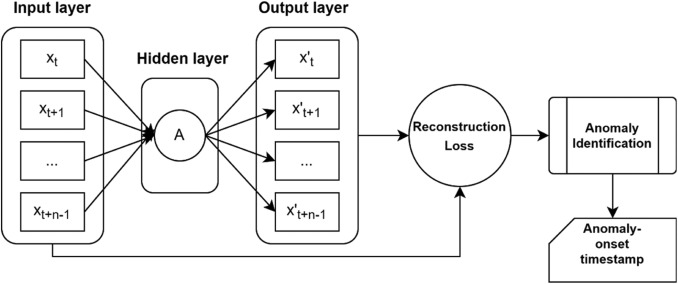

In [51]:
# Predict what the continuing data should look like if healthy
reconstruction = autoencoder.predict(all_sequences)

# MSE Formula - https://en.wikipedia.org/wiki/Mean_squared_error
# Mean Squared Error (MSE) - Metric is indicative of the distance from the truth for a datapoint. The larger the error, the more anomalous that datapoint is to the previous healthy data 
reconstruction_error = np.mean((all_sequences - reconstruction)**2, axis=(1,2)) 
reconstruction_error



# Errors aligned with original timeline (bursts times) NOTE - First burst doesnt have an error (error is corresponds to last burst of each sequence)
error_series = pd.Series(
    reconstruction_error,
    index=df.index[SEQUENCE_LENGTH - 1:]
)
error_series


67/67 [==============================] - 1s 4ms/step


2003-10-22 13:39:13       0.058965
2003-10-22 13:44:13       0.069440
2003-10-22 13:49:13       0.071850
2003-10-22 13:54:13       0.077254
2003-10-22 13:59:13       0.084551
                          ...     
2003-11-25 16:07:32    2014.016205
2003-11-25 23:13:21      54.919925
2003-11-25 23:19:56     159.516397
2003-11-25 23:29:56     357.097218
2003-11-25 23:39:56     654.248639
Length: 2137, dtype: float64

### We now effectively have health scores 

Spikes are indicative of unexpected values, not seen during training (in healthy state). These pick up near the end of the time-series data as expected, beacuse this is where the bearing is wearing out.

The reconstruction loss (distance from predicted "expected healthy" datapoints to the actual datapoint value) are indicative of the machines health. the larger the reconstruction loss/error, the worser the health as it is further from the expected healthy range.

"anomaly scores", "health indicator", "reconstruction error", "reconstruction loss" are interchangable terminology for this:

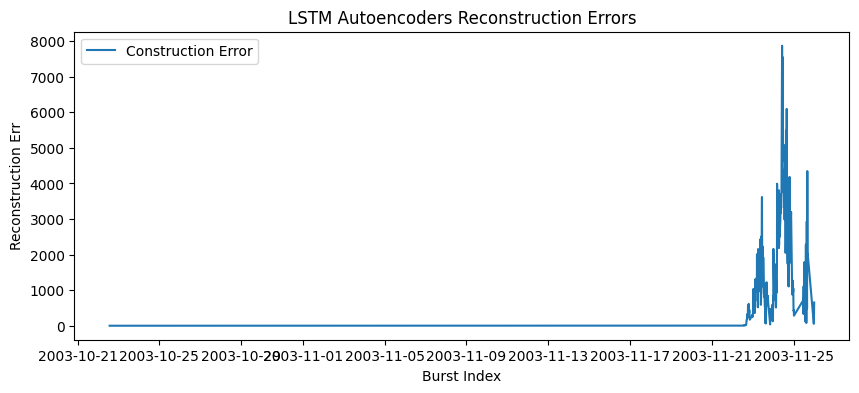

In [52]:
plt.figure(figsize=(10,4))
plt.plot(error_series, label="Construction Error")
plt.title("LSTM Autoencoders Reconstruction Errors")
plt.xlabel("Burst Index")
plt.ylabel("Reconstruction Err")

plt.legend()
plt.show()

### Finding Anomaly onset timestamp 
So after the onset (first genuine anomaly spike), the machine is entering its degradation period

Uses 68-95-99 Rule:
Setting p to the percentage so in Pr function:
- p = 1 = 68%
- p = 2 = 95% 
- p = 3 = 99.7%

Source: https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule

<br>

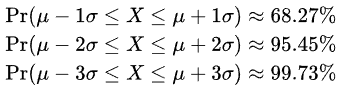

Where:

- X = Each reconstruction error
- σ = Sigma (Std) across the healthy errors (errors during healthy period)
- μ = Mu (Mean) across the healthy errors


Threshold: 552.2428902107594
Abnormal Values found: 1928 (2137 values in total)
Intitial anomaly onset: 2003-11-22 18:06:56


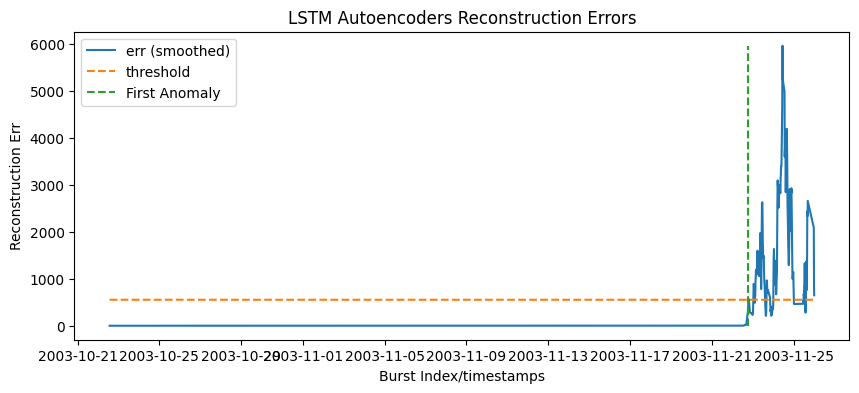

In [70]:
healthy_error = error_series.loc[healthy_df.index[SEQUENCE_LENGTH-1:]]
# Smoothing ensures that anomaly occurances persist over more than one burst (window=5)
# Thus, good for reducing false positives
smoothed_error = error_series.rolling(window=5, min_periods=1).mean()


mu = healthy_error.mean() # mu μ is terminology in math for mean
sigma = healthy_error.std() # Sigma σ is terminology in math for std 

# Formula is "Upper Control Limit" - Three-Sigma Rule (https://www.geeksforgeeks.org/maths/68-95-99-rule/)
threshold = mu + (2 * sigma)
print(f"Threshold: {threshold}")

# Anomalies are those with errors above threshold
# Using 68-95-99.7 rule! - (Also if using p=3, this is known as Three-Sigma Rule)
# p= 1(68%), 2(95%) or 3(99.7%)
p = 3
# Same as probability function (Pr())
anomalies = error_series[(mu - (p*sigma) <= error_series) & (error_series <= mu + (p*sigma))]
print(f"Abnormal Values found: {len(anomalies)} ({len(error_series)} values in total)")


# Beginning of anomalous/unexpected behaviour
first_abnormal_idx = error_series[error_series > threshold].index[0]
print(f"Intitial anomaly onset: {first_abnormal_idx}")

plt.figure(figsize=(10,4))
plt.plot(smoothed_error, label="err (smoothed)")
plt.plot(error_series.index, [threshold for _ in range(len(error_series))], label="threshold", linestyle="--")
plt.plot([first_abnormal_idx,first_abnormal_idx],[0,smoothed_error.max()], label="First Anomaly", linestyle="--")
plt.title("LSTM Autoencoders Reconstruction Errors")
plt.xlabel("Burst Index/timestamps")
plt.ylabel("Reconstruction Err")
plt.legend()
plt.show()

### Important Note before looking at below Estimating RUL
THIS APPROACH IS KNOWING THE FAILURE (tf)
This approach below is using the NASA bearing dataset which is run-to-failure.Therefore, we can use the below forumla as we know when/what tf is (the end of the degradation period is the failure "tf"). 

Using this approach on an unknown machine would require that:
- The machine(s) this entire notebook is calibrated & predicting for are similar in configuration/placement of sensors & structure of machine. (obvious)
- The machine(s) are ran to failure a few times & tracked, to gather degradation period for the RUL regression prediction below

<br>
<hr>

Alternative to the regression based RUL is Health-based RUL.
Where instead of predicting time till failure, we predict the distance to failure in latent health space. 
So, 
- How fast anomaly scores (reconstruction errors) are growing


<br>
<br>
<br>

### Estimating RUL (Regression Based) 
Training data required is the degredation period (near end of life) 

Clip dataset at anomaly onset time to failure (end)

<br>

![RUL Forumla from clipped dataset](media/Regressive_RUL.png)

- ta = First genuine anomaly (anomaly onset time)
- tf = Last datapoints in clipped degradation (failure time)
- t = current datapoint in clipped dataset

In [54]:
# Col is Construction Error (loss)
# for t >= ta
degradation_period = smoothed_error[first_abnormal_idx:]
degradation_period_df = pd.DataFrame(degradation_period, columns=["R_Error"])
# Data is now clipped, from the onset of degradation onwards to end as shown in the paper
degradation_period_df

# Last datapoint (tf)
failure_timestamp = degradation_period_df.index[-1]
failure_timestamp

degradation_period_df["RUL_seconds"] = (failure_timestamp - degradation_period_df.index).total_seconds()
degradation_period_df


,R_Error,RUL_seconds
2003-11-22 18:06:56,357.904087,279180.0
2003-11-22 18:16:56,409.942224,278580.0
2003-11-22 18:26:56,446.639584,277980.0
2003-11-22 18:36:56,504.467383,277380.0
2003-11-22 18:46:56,553.542936,276780.0
...,...,...
2003-11-25 16:07:32,2655.727619,27144.0
2003-11-25 23:13:21,2085.749540,1595.0
2003-11-25 23:19:56,1247.945081,1200.0
2003-11-25 23:29:56,836.340229,600.0


<Axes: >

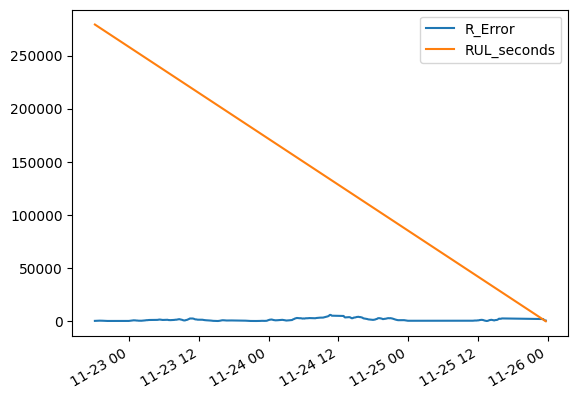

In [55]:
degradation_period_df.plot()

### Estimating RUL (Live Conditinal-Health-Based)
so instead of looking at current t-t_failure, score RUL depending on the speed of increase on the anomaly score (reconstruction errors)

This doesn't give an absolute/exact time of failure - as this is impossible. Although this gives a pretty good indicator that actions are required & the impending failures arising. This is monitors current conditions and the growing change in abnormal sensor readings 

![Health Based RUL forumla from onset onwards](media/HealthBased_RUL.png)

![](media/HealthBased_RUL2.png)


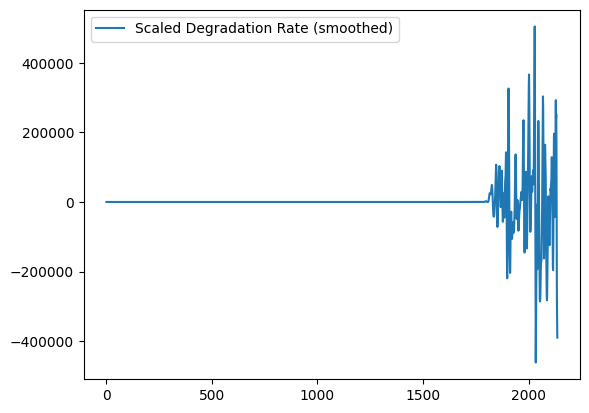

In [56]:
critical_health_threshold = threshold
# Beyond this point, the machine is becoming uncomfortable to continue operating (requires attention & maintanence)
critical_health_threshold

# Slope I believe 
estimated_degradation_rate = np.gradient(smoothed_error.values) # np.gradient(smoothed_error.values)
rate_smoothed = pd.Series(estimated_degradation_rate).rolling(5, min_periods=1).mean()

rate_smoothed

# ?
epsilon = 1e-6

RUL_health = (critical_health_threshold - smoothed_error) / np.maximum(estimated_degradation_rate, epsilon)

plt.plot(rate_smoothed*1000, label="Scaled Degradation Rate (smoothed)")
plt.legend()
plt.show()


Can see unsurity of RUL - As after the first bearing fault (first spike), the health-indicator goes back to its usual (healthy looking) range. When at this point the damage is accumalting, it is masked as the RUL comes back down indicating its healthy

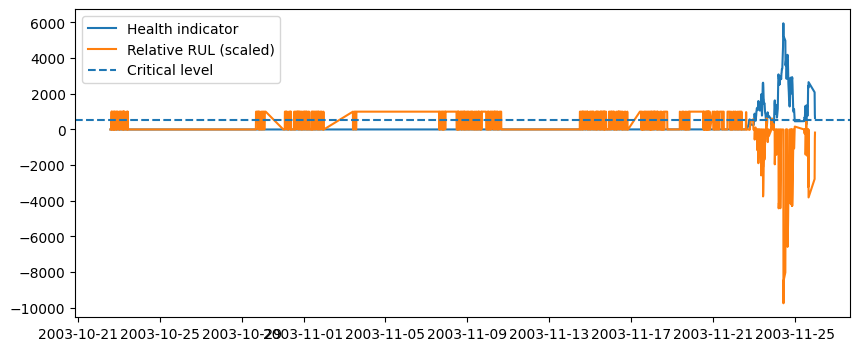

Series([], dtype: float64)


In [57]:
import datetime
plt.figure(figsize=(10,4))
plt.plot(smoothed_error, label="Health indicator")
plt.plot((RUL_health / RUL_health.max())*1000, label="Relative RUL (scaled)")
plt.axhline(critical_health_threshold, linestyle='--', label="Critical level")
plt.legend()
plt.show()

print(RUL_health[datetime.datetime.strptime("2004/02/17 11:00:00", "%Y/%m/%d %H:%M:%S"):])

2137
2136
2136


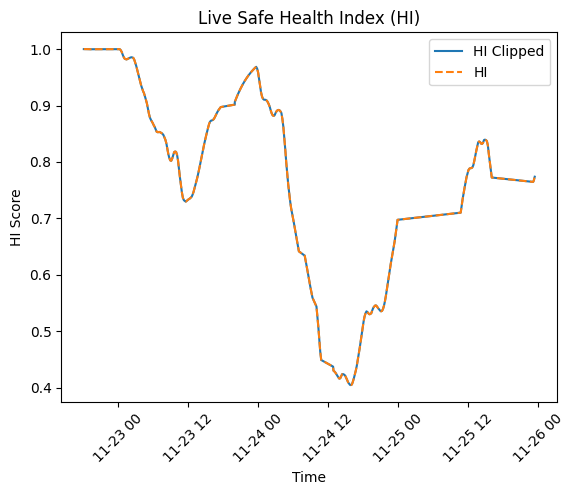

In [79]:
# Damage
ALPHA = 0.95
e = np.maximum(smoothed_error - threshold, 0)

print(len(e))

# Note, remember when you do REVERSE_TIME = anything but 0, it is leaving the rest to be set to
# 0.0 as above defines a series of 0.0s initially.
REVERSE_TIME = 0 # n datapoints to chop off end
damage = pd.Series(0.0, index=e.index[:-1-(REVERSE_TIME-1 if REVERSE_TIME != 0 else 0)]) # Chopping n datapoints off the tail (end)

print(len(damage))

for i in range(1, len(damage)):
    damage.iloc[i] = ALPHA * damage.iloc[i-1] + e.iloc[i]

# Epsilion - Miners Rule
# Causal reference scale
eps = e[e > 0].quantile(0.95)
Dcrit = eps / (1 - ALPHA)
print(len(damage))
# Health Index
# why exponential 
HI = np.exp(-damage / Dcrit)
HI_clipped = HI.clip(0, 1)

plt.plot(HI_clipped.loc[first_abnormal_idx:], label="HI Clipped")
plt.plot(HI.loc[first_abnormal_idx:], label="HI", linestyle="--")
plt.xticks(rotation=45)
plt.title("Live Safe Health Index (HI)")
plt.ylabel("HI Score")
plt.xlabel("Time")
plt.legend()
plt.show()


Health Index (HI)

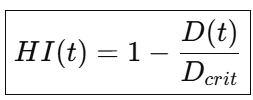

<br>

And clipped (at 1.0-0)

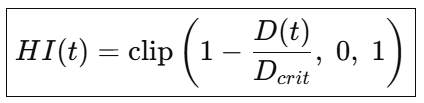

first anomaly:  2003-11-22 18:06:56
Min D: 0.0; Max D: 60249.36086874454; Dcrit: 59211.520490361785


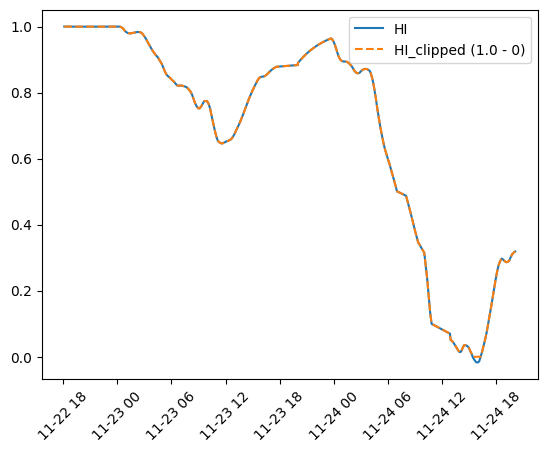

In [59]:
# Temp block - Trial and error (testing block)

print("first anomaly: ", first_abnormal_idx)
# .95 = Conservative fatigue
# .97 = slow degradation
# .99 = safety critical assets ?? 
ALPHA = .95

e = np.maximum(smoothed_error - threshold, 0)
damage = pd.Series(index=e.index, dtype=float)
damage.iloc[0] = 0

# NOT LIVE - Removing below datapoints from end always results in a final Health Index of 0...
TEST_LIVE = 60
for i in range(1, len(e)-TEST_LIVE):
    damage.iloc[i] = (ALPHA * damage.iloc[i-1]) + e.iloc[i]


# Accumalated Damage
D = damage
Dcrit = D.loc[first_abnormal_idx:].quantile(.98) #threshold # Dcrit = D.quantile(.939)

print(f"Min D: {D.min()}; Max D: {D.max()}; Dcrit: {Dcrit}")

HI = 1 - (D / Dcrit)

HI_clipped = HI.clip(0, 1)

# plt.plot(D.loc[first_abnormal_idx:] / D.loc[first_abnormal_idx].min(), label="Damage Rate (Diff)", linestyle="--")
# plt.plot(error_series[first_abnormal_idx:], label="Reconstruction Err")
plt.plot(HI.loc[first_abnormal_idx:], label="HI")
plt.plot(HI_clipped.loc[first_abnormal_idx:], label="HI_clipped (1.0 - 0)", linestyle="--")

plt.legend()
plt.xticks(rotation=45)
plt.show()

<Axes: >

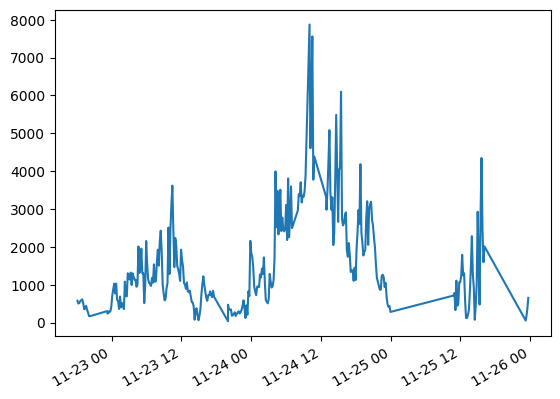

In [60]:
error_series[first_abnormal_idx:].plot()

Changing to monotonic damage accumulation
- After the damage spike, dont decrease RUL back down to baseline

<hr>

<ins>Using Cummulative Summative:</ins> <br>
cumsum([1, 3, 5, 7])
1. 1
2. 4
3. 9
4. 16


<ins>Explanation:</ins>
1. 1
2. 1+3 = 4
3. 4+5 = 9
4. 9+7 = 16


Quantile is the value(s) in a distribution that is at the qth quantile (percent) 
<br>so, in [20, 10, 15, 5, 25] (min=5, max=25)
- quantile(.01) = 5.2 (around 5 as 1% margin in distrubution is near lowest which is 5)
- quantile(.25) = 10
- quantile(.50) = 15 (Half way point, also known as MEDIAN)
- quantile(.75) = 20 
- quantile(.99) = 24.8 (.1 or 100% will equal 25 and this is the largest in array)

first anomaly:  2003-11-22 18:06:56


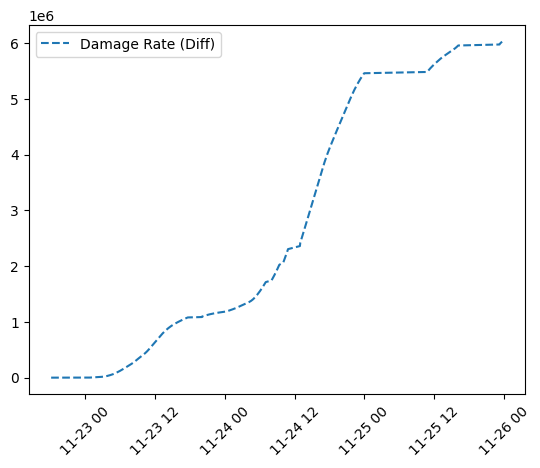

In [61]:
# Temp block - Trial and error (testing block)

print("first anomaly: ", first_abnormal_idx)
# .95 = Conservative fatigue
# .97 = slow degradation
# .99 = safety critical assets ?? 
ALPHA = .95

e = np.maximum(smoothed_error - threshold, 0)
damage = pd.Series(index=e.index, dtype=float)
damage.iloc[0] = 0


for i in range(1, len(e)):
    damage.iloc[i] = (ALPHA * damage.iloc[i-1]) + e.iloc[i]


# Accumalated Damage
D = damage.cumsum()

plt.plot(D.loc[first_abnormal_idx:], label="Damage Rate (Diff)", linestyle="--")
# plt.plot(RUL / RUL.min(), label="Remaining Useful Life (RUL)")
# plt.plot(RUL2, label="RUL2")
# plt.plot(test, label="Damage Rate with Memory")
plt.legend()
plt.xticks(rotation=45)
plt.show()

if False:
    # NOTE, the damage increases dramatically over time. Current time writing this note
    # The RUL dimishes more near the end as these are much more impactful
    print("first over threshold value: ", damage.loc[damage>0].index[0], " with value ", damage.loc[damage>0][0] )
    print("\nDamages: ", damage.loc[damage>0])
    # print(damage)#.plot()

    # Same damage-rate cacluation (difference between neighbours identifies contiguous changes)
    WINDOW = 10
    damage_rate = damage.diff(WINDOW) / WINDOW
    impactful_damage_rate = damage_rate[damage_rate>0]
    lowest_rate_of_change = impactful_damage_rate.quantile(.1)
    highest_rate_of_change = impactful_damage_rate.quantile(.99)
    print("\nLowest rate of change in impactful (>0) data rate: ", lowest_rate_of_change)
    print("Highest rate of change in impactful (>0) data rate: ", highest_rate_of_change)

    # Clip Lower bounds - to make smaller damage rates have no impact (damage ranges < .1 quantile, will ?)
    lower_boundary = impactful_damage_rate.quantile(.1) 
    # Set (clip) values below the lowest_rate_of_change to this boundary (-2, -1, 2 < 1 -> clip -> 1, 1, 2)
    damage_rate = damage_rate.clip(lower=lower_boundary) # clip values to > .000001
    print("Damage Rage: ", damage_rate)



    # "In historical data, 99.5% of the time damage was below "
    critical_damage_score = damage.quantile(.95)
    print("Critical damage score: ", critical_damage_score)


    active_mask = damage > 0
    RUL = pd.Series(index=damage.index, dtype=float)
    print(RUL[1])

    STARTING_SCORE = 0
    damage_rate = damage_rate.loc[first_abnormal_idx:]
    damage_rate_w_memory = damage_rate.cummax()
    print("damage rate with mem: ", damage_rate_w_memory)


    damage_memory = (damage.cummax())
    RUL2 = damage + damage_rate_w_memory#.quantile(.95)

    IMPACT_ON_RUL = .2
    #RUL = (((STARTING_SCORE-damage) / (damage_rate*2)) - (damage - damage_rate_w_memory)) * IMPACT_ON_RUL

    RUL = -((((damage + damage_rate_w_memory)*IMPACT_ON_RUL)))
    RUL = -((((smoothed_error+damage_rate_w_memory) * (damage_rate*.002))))

    # RUL = -((((smoothed_error / damage_rate))+(damage_rate_w_memory)))
    #RUL = -((((smoothed_error / damage_rate)*IMPACT_ON_RUL)+(damage_rate_w_memory)))


    RUL = RUL[first_abnormal_idx:]
    # RUL.plot()

    # BOOL-Series, Get where confident degration is real
    # Sets true there damage is more than the upper-qauter quantile (top/highest 25% damage scores will be true)
    confidence = (damage > damage.quantile(.75)) #(damage > damage.quantile(.75))
    # RUL.plot()
    print("Confidence: ", confidence)

    print("Confidence is true: ", confidence.loc[confidence].index)
    # RUL.loc[1] = 100


    # RUL.loc[confidence] = np.maximum.accumulate(
    #     RUL.loc[confidence][::-1]
    # )[::-1]
    # RUL = RUL.abs()
    # RUL.plot()

    print("RUL Estimation begins: ", RUL.index[0])

    if False:
        beginning_of_RUL_diminish = RUL[RUL>1750].index[-1]
        print("\nBeginning of dimishinment of RUL ", beginning_of_RUL_diminish)
        print("damage rate at this time: ", damage_rate[beginning_of_RUL_diminish - datetime.timedelta(hours=0)])
        # I dunno


    print(RUL.index[0])

    #plt.subplot2grid((2,1))
    plt.plot(damage.loc[first_abnormal_idx:], label="damage")
    plt.plot(error_series.loc[first_abnormal_idx:], label="Reconstuction Errors (AE)", linestyle="--")
    plt.plot(damage_rate.loc[first_abnormal_idx:], label="Damage Rate (Diff)", linestyle="--")
    # plt.plot(RUL / RUL.min(), label="Remaining Useful Life (RUL)")
    # plt.plot(RUL2, label="RUL2")
    # plt.plot(test, label="Damage Rate with Memory")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

In [62]:
damage = smoothed_error.copy()
# Set Non-Impactful rows (below threshold) to 0 - This brings ALL erros down by (-threshold)
# This is the same as doing:
# excess = smoothed_err - thres; (sub threshold from each error reading)
# excess_clipped = excess[excess < 0] = 0; (Set negative values to 0)
excess = np.maximum(smoothed_error - threshold, 0)
# print(excess.loc[excess > 0])




# print(threshold)
# damage[first_abnormal_idx:] = 0 # Below breaking threshold, not damaged, set to 0 to have no effect
damage = excess.cumsum() # Accumalative - retains previous errors
print(damage)
print(f"First anomaly: {damage[first_abnormal_idx]}")

WINDOW = 10
damage_rate = damage.diff(WINDOW) / WINDOW
damage_rate = damage_rate.clip(lower=1e-6) # clip values to > .000001


baseline = 5
critical_damage_threshold = baseline * damage[damage > 0].median() # Live 
critical_damage_threshold = 1.05 * damage.iloc[-1]
print(f"critical_damage_threshold ({critical_damage_threshold}) = 1.05 * {damage.iloc[-1]}")


# TODO
# Maybe try scaling damage down to make RUL less sensitive - already usnig cumsum to retain
# previous damage spikes
a = (critical_damage_threshold - damage)
print(a)
RUL_health_history = (a - damage) / damage_rate
# RUL_health = np.clip(RUL_health, 0, None)


2003-10-22 13:39:13         0.000000
2003-10-22 13:44:13         0.000000
2003-10-22 13:49:13         0.000000
2003-10-22 13:54:13         0.000000
2003-10-22 13:59:13         0.000000
                           ...      
2003-11-25 16:07:32    314153.104051
2003-11-25 23:13:21    315686.610700
2003-11-25 23:19:56    316382.312891
2003-11-25 23:29:56    316666.410230
2003-11-25 23:39:56    316762.127017
Length: 2137, dtype: float64
First anomaly: 0.0
critical_damage_threshold (332600.2333677239) = 1.05 * 316762.12701687985
2003-10-22 13:39:13    332600.233368
2003-10-22 13:44:13    332600.233368
2003-10-22 13:49:13    332600.233368
2003-10-22 13:54:13    332600.233368
2003-10-22 13:59:13    332600.233368
                           ...      
2003-11-25 16:07:32     18447.129317
2003-11-25 23:13:21     16913.622667
2003-11-25 23:19:56     16217.920477
2003-11-25 23:29:56     15933.823137
2003-11-25 23:39:56     15838.106351
Length: 2137, dtype: float64


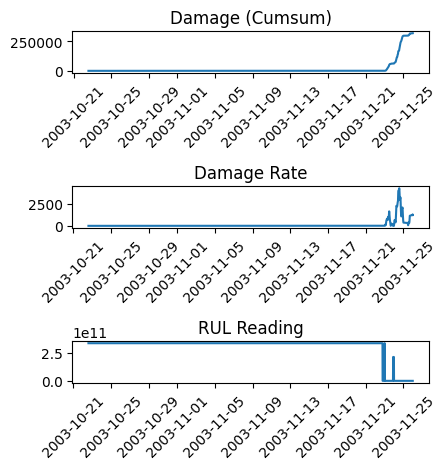

In [63]:
# Ploting
damage_plot = plt.subplot2grid((3,3), (0,0), colspan=2)
damage_rate_plot = plt.subplot2grid((3,3), (1,0), colspan=2)
RUL_plot = plt.subplot2grid((3,3), (2,0), colspan=2)


# Can see it retains the previous bearing faults 
# Damage
damage_plot.plot(damage)
damage_plot.set_title("Damage (Cumsum)")
damage_plot.tick_params(axis="x", labelrotation=45)


# Damage Rate
damage_rate_plot.plot(damage_rate)
damage_rate_plot.set_title("Damage Rate")
damage_rate_plot.tick_params(axis="x", labelrotation=45)

# Rul
RUL_plot.plot(RUL_health_history)
RUL_plot.set_title("RUL Reading")
RUL_plot.tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.show()


First burst (2003-11-22 18:06:56) with detected anomaly & onwards:
2003-11-24 05:11:24     96.588930
2003-11-24 05:21:24     83.952732
2003-11-24 05:31:24     73.938736
2003-11-24 05:41:24     66.443946
2003-11-24 05:51:24     62.321119
                          ...    
2003-11-25 16:07:32   -260.565572
2003-11-25 23:13:21   -240.431162
2003-11-25 23:19:56   -232.358433
2003-11-25 23:29:56   -237.367582
2003-11-25 23:39:56   -248.362239
Length: 132, dtype: float64


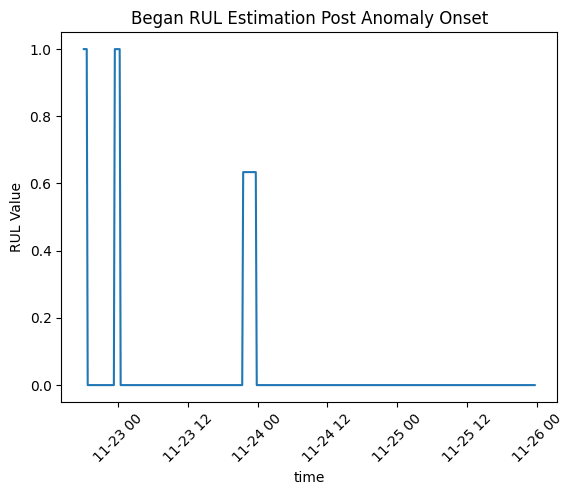

In [64]:
RUL_Health_series = pd.Series(RUL_health_history)
RUL_post_onset = RUL_Health_series[first_abnormal_idx:]

print(f"First burst ({first_abnormal_idx}) with detected anomaly & onwards:\n{RUL_post_onset[RUL_Health_series < 100]}")


plt.plot(RUL_post_onset / RUL_post_onset.max())
plt.title("Began RUL Estimation Post Anomaly Onset")
plt.ylabel("RUL Value")
plt.xlabel("time")
plt.xticks(rotation=45)
plt.show()

NameError: name 'RUL' is not defined

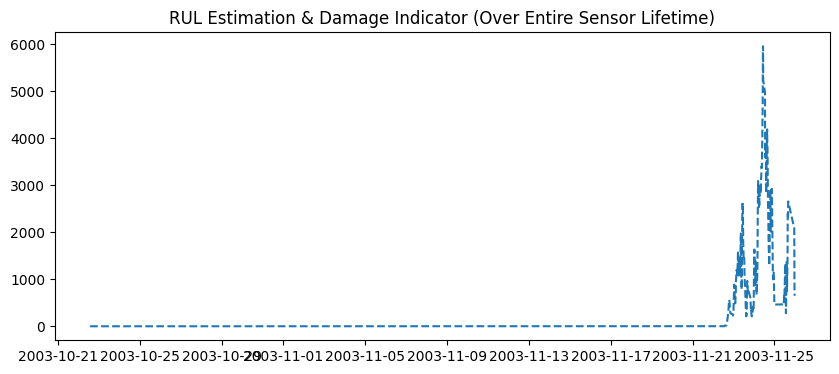

In [65]:
import datetime

plt.figure(figsize=(10,4))
plt.title("RUL Estimation & Damage Indicator (Over Entire Sensor Lifetime)")
plt.plot(smoothed_error, label="Detected Damage", linestyle="--")
plt.plot((RUL / RUL.max())*10000, label="RUL")
plt.legend()
plt.show()

print(RUL_health[datetime.datetime.strptime("2004/02/17 11:00:00", "%Y/%m/%d %H:%M:%S"):])